In [1]:
!pip install rdkit
!pip install chembl_structure_pipeline

  Using cached pillow-12.2.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 4.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 8.8 MB/s eta 0:00:0000:0100:01
Using cached pillow-12.2.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (7.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [rdkit]32m2/3 [rdkit]

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


**0. Importación de módulos y paquetes necesarios**

Importe todos los módulos y paquetes necesarios para el desarrollo de las actividades (por ejemplo: pandas, numpy, rdkit, etc.), incluyendo comentarios breves que expliquen para qué se usará cada paquete principal.

In [23]:
# Librería para manipulación y análisis de datos en estructuras tipo DataFrame
import pandas as pd
# Librería para operaciones numéricas y manejo de arreglos multidimensionales
import numpy as np
# Librería para poder mostrar gráficas
import matplotlib.pyplot as plt
# Módulo principal de RDKit para crear y manipular moléculas a partir de SMILES
from rdkit import Chem
# Submódulo de RDKit para dibujar y generar imágenes de estructuras químicas
from rdkit.Chem import Draw
# Función de Jupyter/IPython para mostrar imágenes en la celda
from IPython.display import display
from chembl_structure_pipeline import standardizer
# Función para importar el cálculo el Scaffold de Bemis y Murcko
from rdkit.Chem.Scaffolds import MurckoScaffold
# Para poder calcular los descriptores de Lipinski y Veber
from rdkit.Chem import rdMolDescriptors
# Importamos Seaborn para poder visualizar nuestros datos
import seaborn as sns
# Importamos AllChem para poder calcular fingerprints
from rdkit.Chem import rdFingerprintGenerator
from sklearn.decomposition import PCA

ModuleNotFoundError: No module named 'sklearn'

**1. Carga de datos**

Lea como DataFrame de pandas las dos quimiotecas proporcionadas y responda:

*   ¿Cuántos compuestos distintos (SMILES) tienen alguna actividad reportada contra el Factor de Coagulación X?

*   ¿Cuántos compuestos distintos (SMILES) incluye la colección de ENAMINE proporcionada?

In [7]:
# Cargamos los archivos como DataFrame usando pandas
enamine = pd.read_csv('data/YoatzinTorres-Enamine_DD10.csv')
bioactivity = pd.read_csv('data/YoatzinTorres-Bioactivity_data.csv')

print("¿Cuántos compuestos distintos (SMILES) tienen alguna actividad reportada contra el Factor de Coagulación X?")
# Para resolver esta pregunta, primero filtramos con 'loc' para seleccionar todas las columnas que cumplan con
# tener alguna actividad reportada contra el Factor de Coagulación X, y una vez filtrada esa información,
# realizamos el conteo de cuantos Smiles distintos se han reportado.
print(bioactivity.loc[bioactivity["Target Name"] == "Coagulation factor X", "Smiles"].nunique())
# Para esta preguunta, ocupamos la función de pandas 'nunique', que hace un conteo de elementos
# distintos, para este ejercicio la información dada es únicamente la columna SMILES del archivo enamine
print("¿Cuántos compuestos distintos (SMILES) incluye la colección de ENAMINE proporcionada?")
print(enamine["SMILES"].nunique())

¿Cuántos compuestos distintos (SMILES) tienen alguna actividad reportada contra el Factor de Coagulación X?
7669
¿Cuántos compuestos distintos (SMILES) incluye la colección de ENAMINE proporcionada?
10240


**Breve discusión**

**2. Preparación de los datos**

Para el conjunto de datos de compuestos bioactivos:
*   Conserve solamente los datos que tengan un valor de "pChEMBL Value" asociado y cuya actividad haya sido medida como "Ki".
*   Responda, ¿En el conjunto de datos filtrado hay compuestos duplicados?. De ser así, elimine duplicados (por Smiles) conservando solo el valor de afinidad más alto reportado para cada compuesto.
*   Responda, ¿Hay fármacos aprobados en el conjunto de datos final?. De ser así, indique cuántos son y muestre sus estructuras.

Conserve solamente los datos que tengan un valor de "pChEMBL Value" asociado y cuya actividad haya sido medida como "Ki".
Responda, ¿En el conjunto de datos filtrado hay compuestos duplicados?. De ser así, elimine duplicados (por Smiles) conservando solo el valor de afinidad más alto reportado para cada compuesto.
¿Existen duplicados? Sí

Responda, ¿Hay fármacos aprobados en el conjunto de datos final?. De ser así, indique cuántos son y muestre sus estructuras.
Total de farmacos aprobados:  6


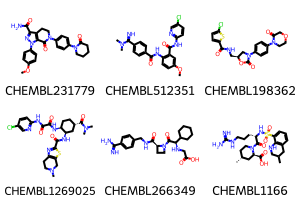

In [5]:
print("""Conserve solamente los datos que tengan un valor de "pChEMBL Value" asociado y cuya actividad haya sido medida como "Ki".""")
# Para resolver este punto, lo que tenemos que hacer es, nuevamente con 'loc', de nuestro df bioactivity filtramos
# los que en la columna 'Standard Type' sea 'Ki' y que tenga un valor en 'pChEMBL Value'
filtered_bioactivity = bioactivity.loc[
    (bioactivity["Standard Type"] == "Ki") &
    (bioactivity["pChEMBL Value"].notnull())
]

print("Responda, ¿En el conjunto de datos filtrado hay compuestos duplicados?. De ser así, elimine duplicados (por Smiles) conservando solo el valor de afinidad más alto reportado para cada compuesto.")
# Para responder esta pregunta son dos partes, para saber si hay duplicados podemos hacer una comparación entre el número total
# y el número de distintos con una columna que no esté nula en ningún caso. Ej. Smiles
duplicados = filtered_bioactivity["Smiles"].count != filtered_bioactivity["Smiles"].nunique()
print(f"¿Existen duplicados? {'Sí' if duplicados else 'No'}")
# Continuando con la siguiente parte, tenemos que hacer un nuevo filtrado para eliminar los 'Smiles' repetidos conservando
# el que tiene el valor de afinidad más alto reportado, para hacer esto, ordenamos de mayor a menor por la columna 'pChEMBL Value'
# y de la columna Smiles mantenemos siempre el primer resultado y eliminamos los demás
filtered_bioactivity_max = (
    filtered_bioactivity
    .sort_values("pChEMBL Value", ascending=False)
    .drop_duplicates(subset="Smiles", keep="first")
    .reset_index(drop=True)
)

print("\nResponda, ¿Hay fármacos aprobados en el conjunto de datos final?. De ser así, indique cuántos son y muestre sus estructuras.")
# Esta pregunta nuevamente se responde en dos partes, primero extraemos del df final todos aquellos que cuentan con un
# “Molecule Max Phase” de la base de datos “bioactivity” igual a 4
farmacos_aprobados = filtered_bioactivity_max.loc[
    filtered_bioactivity_max["Molecule Max Phase"] == 4
]
# Con el df final, filtramos aquellos que en Molecule Max Phase su valor sea igual a 4 e imprimimos el conteo de los
# que cumplan esa condición.
print(f"Total de farmacos aprobados: ", farmacos_aprobados["Smiles"].count())
# Para la segunda parte, obtenemos el Molecule ChEMBL ID de los fármacos aprobados
# junto con sus estructuras químicas generadas a partir de la columna 'Smiles'
# usando la librería Chem de RDKit.

# Creamos una nueva columna 'Mol' en el DataFrame con los objetos Mol de RDKit
farmacos_aprobados = farmacos_aprobados.assign(
    Mol=farmacos_aprobados["Smiles"].apply(Chem.MolFromSmiles)
)

# Extraemos todos los IDs de moléculas (Molecule ChEMBL ID) en una lista .head(n)
# asegura que tomamos el mismo número de registros que el conteo de 'Smiles'
ids = farmacos_aprobados["Molecule ChEMBL ID"].head(farmacos_aprobados["Smiles"].count()).tolist()
# Extraemos todas las estructuras químicas (Mol) en una lista
mols = farmacos_aprobados["Mol"].head(farmacos_aprobados["Smiles"].count()).tolist()

# Generamos una imagen en cuadrícula con las moléculas y sus IDs como leyendas
img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(100,100), legends=ids)
display(img)

**Breve discusión**

Para ambos conjuntos de datos:
*   Aplique el proceso de estandarización de ChEMBL a todos los SMILES, añadiendo en una nueva columna (Canonical SMILES) el resultado de este proceso.
*   A partir del Canonical SMILES generado, añada una nueva columna con el InChiKey para cada uno de los compuestos.
*   Responda, ¿Se identificaron duplicados dentro de cada conjunto de datos después de la estandarización?
*   En caso de identificar nuevos duplicados, eliminelos conservando la primera ocurrencia de cada uno de ellos en los respectivos conjuntos de datos.
*   Responda, ¿Hay compuestos que ocurren en ambas bases de datos? De ser así, identifiquelos y muestre sus estructuras. Posteriormente eliminelos del conjunto de datos de Enamine.

In [18]:
print("Aplique el proceso de estandarización de ChEMBL a todos los SMILES, añadiendo en una nueva columna (Canonical SMILES) el resultado de este proceso.")
# Para este punto, primero definimos la función para la estandarización de ChEMBL ocupando 'standardizer'
def smiles_standardizer(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol != None:
        std_mol = standardizer.standardize_mol(mol)
        parent_mol = standardizer.get_parent_mol(std_mol)[0]
        Chem.SanitizeMol(parent_mol)
        return Chem.MolToSmiles(parent_mol)
    else:
        return None
# Una vez definida nuestra función, agregamos la columna 'Canonical SMILES' a ambos conjuntos de datos aplicando la misma con
# su respectiva columna de Smiles
enamine["Canonical SMILES"] = enamine["SMILES"].apply(smiles_standardizer)
bioactivity["Canonical SMILES"] = bioactivity["Smiles"].apply(smiles_standardizer)
print("\nA partir del Canonical SMILES generado, añada una nueva columna con el InChiKey para cada uno de los compuestos.")
# A partir del Canonical SMILES generado, añadimos una nueva columna con el InChIKey
# Para cada compuesto, convertimos el Canonical SMILES en un objeto Mol y luego en InChIKey
enamine["InChIKey"] = enamine["Canonical SMILES"].apply(
    lambda x: Chem.MolToInchiKey(Chem.MolFromSmiles(x)) if x else None
)
bioactivity["InChIKey"] = bioactivity["Canonical SMILES"].apply(
    lambda x: Chem.MolToInchiKey(Chem.MolFromSmiles(x)) if x else None
)
# Para responder este punto, hacemos la comparación del ejercicio anterior, comparamos el total de valores encontrados en
# 'Canonical Smiles' de cada conjunto con el total de 'Canonical Smiles' únicos
print("\nResponda, ¿Se identificaron duplicados dentro de cada conjunto de datos después de la estandarización?")
duplicados_std_enamine = enamine["Canonical SMILES"].count != enamine["Canonical SMILES"].nunique()
print(f"¿Existen duplicados en Enamine? {'Sí' if duplicados_std_enamine else 'No'}")
duplicados_std_bioactivity = bioactivity["Canonical SMILES"].count != bioactivity["Canonical SMILES"].nunique()
print(f"¿Existen duplicados en Bioactivity? {'Sí' if duplicados_std_enamine else 'No'}")

print("\nEn caso de identificar nuevos duplicados, eliminelos conservando la primera ocurrencia de cada uno de ellos en los respectivos conjuntos de datos.")
# Para resolver este punto, hacemos un nuevo DF ordenando ambos conjuntos por 'Canonical SMILES' y conservando la primer coincidencia
# y eliminando las demas coincidencias en dicha columna y reinciando el índice para que en el DF resultante no realice saltos
filtered_new_enamine = (
    enamine
    .sort_values("Canonical SMILES", ascending=False)
    .drop_duplicates(subset="Canonical SMILES", keep="first")
    .reset_index(drop=True)
)

filtered_new_bioactivity = (
    bioactivity
    .sort_values("Canonical SMILES", ascending=False)
    .drop_duplicates(subset="Canonical SMILES", keep="first")
    .reset_index(drop=True)
)
print("\nResponda, ¿Hay compuestos que ocurren en ambas bases de datos? De ser así, identifiquelos y muestre sus estructuras. Posteriormente eliminelos del conjunto de datos de Enamine.")
# Para este punto, primero tenemos que encontrar los compuestos que se encuentren en ambos DF finales, para esto ocupamos intersection()
# tomando las 'Canonical SMILES' como parámetro
smiles_comunes = set(filtered_new_enamine["Canonical SMILES"]).intersection(
    set(filtered_new_bioactivity["Canonical SMILES"])
)
# Imprimimos el total para saber si existe alguna coincidencia
print("Número de SMILES en común:", len(smiles_comunes))


Aplique el proceso de estandarización de ChEMBL a todos los SMILES, añadiendo en una nueva columna (Canonical SMILES) el resultado de este proceso.


[13:32:04] Running Normalizer
[13:32:04] Running Uncharger
[13:32:04] Running Uncharger
[13:32:04] Running Uncharger
[13:32:04] Running Normalizer
[13:32:04] Running Uncharger
[13:32:04] Running Uncharger
[13:32:04] Running Uncharger
[13:32:04] Running Normalizer
[13:32:04] Running Uncharger
[13:32:04] Running Uncharger
[13:32:04] Running Uncharger
[13:32:04] Running Normalizer
[13:32:04] Running Uncharger
[13:32:04] Running Uncharger
[13:32:04] Running Uncharger
[13:32:04] Running Normalizer
[13:32:04] Running Uncharger
[13:32:04] Running Uncharger
[13:32:04] Running Uncharger
[13:32:04] Running Normalizer
[13:32:04] Running Uncharger
[13:32:04] Running Uncharger
[13:32:04] Running Uncharger
[13:32:04] Running Normalizer
[13:32:04] Running Uncharger
[13:32:04] Running Uncharger
[13:32:04] Running Uncharger
[13:32:04] Running Normalizer
[13:32:04] Running Uncharger
[13:32:04] Running Uncharger
[13:32:04] Running Uncharger
[13:32:04] Running Normalizer
[13:32:04] Running Uncharger
[13:3


A partir del Canonical SMILES generado, añada una nueva columna con el InChiKey para cada uno de los compuestos.

Responda, ¿Se identificaron duplicados dentro de cada conjunto de datos después de la estandarización?
¿Existen duplicados en Enamine? Sí
¿Existen duplicados en Bioactivity? Sí

En caso de identificar nuevos duplicados, eliminelos conservando la primera ocurrencia de cada uno de ellos en los respectivos conjuntos de datos.

Responda, ¿Hay compuestos que ocurren en ambas bases de datos? De ser así, identifiquelos y muestre sus estructuras. Posteriormente eliminelos del conjunto de datos de Enamine.
Número de SMILES en común: 0


**Breve discusión**

**3. Análisis de Scaffolds**

*   Cálcule el Scaffold de Bemis y Murcko (en formato SMILES) para cada compuesto en ambos conjuntos de datos.
*   Responda, ¿Cuántos Scaffolds únicos hay en cada conjunto de datos Considerando la relación entre el número de Scaffolds únicos respecto al número de moléculas en cada conjunto, ¿qué conjunto de datos es más diverso?, ¿Hay Scaffolds que aparezcan en ambos conjutnos de datos? De ser así, identfíquelos, muestre sus estructuras y posteriormente eliminelos del conjunto de datos de Enamine.

Cálcule el Scaffold de Bemis y Murcko (en formato SMILES) para cada compuesto en ambos conjuntos de datos.


[11:40:12] 

****
Pre-condition Violation
bad bond stereo
Violation occurred on line 362 in file /project/build/temp.linux-x86_64-cpython-311/rdkit/Code/GraphMol/Canon.cpp
Failed Expression: dblBond->getStereo() > Bond::STEREOANY
----------
Stacktrace:
----------
****

[11:40:12] 

****
Pre-condition Violation
bad bond stereo
Violation occurred on line 362 in file /project/build/temp.linux-x86_64-cpython-311/rdkit/Code/GraphMol/Canon.cpp
Failed Expression: dblBond->getStereo() > Bond::STEREOANY
----------
Stacktrace:
----------
****

[11:40:14] 

****
Pre-condition Violation
bad bond stereo
Violation occurred on line 362 in file /project/build/temp.linux-x86_64-cpython-311/rdkit/Code/GraphMol/Canon.cpp
Failed Expression: dblBond->getStereo() > Bond::STEREOANY
----------
Stacktrace:
----------
****



Enamine
                                            SMILES  \
0      C1=CN(C=N1)C=2C=CC(=CC2)CNCC3=CN4CCCCCC4=N3   
1     CN1N=C(C2=NN=C(COC3CCCCC3)O2)C=4C=CC=CC4C1=O   
2   COC1=CN=C(NC1=O)C2(CCCC2)NCC=3C=CC=4C=CC=CC4C3   
3  CN1C=C(CN[C@H]2C=3C=CC=CC3C[C@@H]2O)C(=N1)C4CC4   
4  O=C(C=1C=CN=C(N1)C=2C=CC=CC2)N3CCC(=O)NCC43COC4   

                            BemisMurckoScaffold  
0       c1cn(-c2ccc(CNCc3cn4c(n3)CCCCC4)cc2)cn1  
1     O=c1[nH]nc(-c2nnc(COC3CCCCC3)o2)c2ccccc12  
2      O=c1ccnc(C2(NCc3ccc4ccccc4c3)CCCC2)[nH]1  
3              c1ccc2c(c1)CCC2NCc1c[nH]nc1C1CC1  
4  O=C1CCN(C(=O)c2ccnc(-c3ccccc3)n2)C2(CN1)COC2  
Bioactivity
                                              Smiles  \
0  CN(C)Cc1ccccc1-c1ccc(-n2cnc3c(C(F)(F)F)nn(-c4c...   
1  Cc1nn(-c2ccc3onc(N)c3c2)c2c(=O)n(-c3ccc(-c4ccc...   
2  CN(C)Cc1ccccc1-c1ccc(N2CNc3c(C(F)(F)F)nn(-c4cc...   
3  Cc1nc2c(C(F)(F)F)nn(-c3ccc4onc(N)c4c3)c2c(=O)n...   
4  Cc1nn(-c2ccc3onc(N)c3c2)c2c(=O)n(-c3ccc(-c4ccc...   

                  

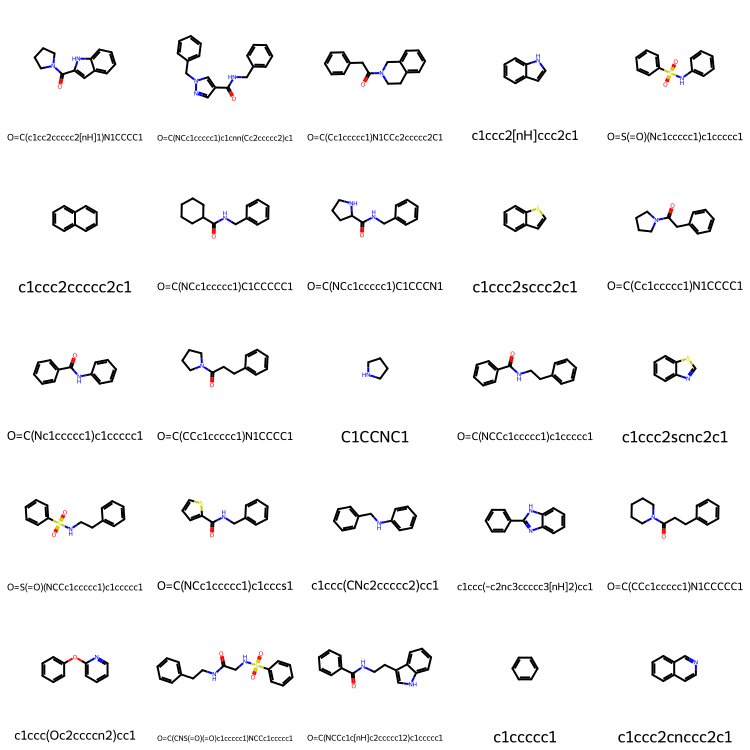

Tamaño original del conjunto Enamine: 10240
Tamaño después de eliminar Scaffolds repetidos: 10146


In [5]:
print("Cálcule el Scaffold de Bemis y Murcko (en formato SMILES) para cada compuesto en ambos conjuntos de datos.")
# Para responder este punto, ocupamos la función MurckoScaffoldSmilesFromSmiles en cada conjunto de datos y agregamos la columna
# a ambos DataFrame como una columna extra

# Definimos una función auxiliar, ya que, el primer cálculo se hizo de la siguiente forma:
"""
bioactivity["BemisMurckoScaffold"] = bioactivity["Smiles"].apply(
    lambda x: MurckoScaffold.MurckoScaffoldSmilesFromSmiles(x) if x else None
)
"""
# Esta generaba algún tipo de conflicto, por lo que en caso de suceder este error, atrapamos el error
# y se manda null el dato para no interrumpir las demás operaciones
def safe_bemis_murcko(smiles):
    if not smiles:
        return None
    try:
        return MurckoScaffold.MurckoScaffoldSmilesFromSmiles(smiles)
    except Exception:
        return None
# Ahora construimos la nueva columna pasando la columna Smiles de cada DF pasando por nuestra función
enamine["BemisMurckoScaffold"] = enamine["SMILES"].apply(safe_bemis_murcko)
bioactivity["BemisMurckoScaffold"] = bioactivity["Smiles"].apply(safe_bemis_murcko)
# Validamos que ahora si se lleven a cabo los cálculos
print("Enamine")
print(enamine[["SMILES", "BemisMurckoScaffold"]].head())
print("Bioactivity")
print(bioactivity[["Smiles", "BemisMurckoScaffold"]].head())
"""
# USO DE IA: Para poder saber porque está fallando, previamente se realizó una generación indivual de cada conjunto y se pudo
# observar que el conjunto que tiene error es bioactivity, entonces generamos un sublista con todos los compuestos que no se
# les pudo calcular el Scaffold de Bemis y Murcko, nos apoyamos de la IA para poder saber a que se debe el que no lleve a cabo
# el cálculo, por lo que se le envía lo siguiente:
# Uno de los SLIMES a los que no se les está pudiendo realizar el cálculo con la función MurckoScaffold.MurckoScaffoldSmilesFromSmiles
# es 'Cc1nn(-c2ccc3onc(N)c3c2)c2c1CCN(c1ccc(-c3ccccc3CN3CC[C@@H](O)C3)cc1)C2=O', ¿a que se debe que falle? Obteniendo como respuesta:
# El SMILES que compartiste: Cc1nn(-c2ccc3onc(N)c3c2)c2c1CCN(c1ccc(-c3ccccc3CN3CC[C@@H](O)C3)cc1)C2=O está fallando porque contiene
# estereoquímica explícita en un doble enlace o en un centro quiral que RDKit no puede interpretar correctamente al generar el scaffold.
print("Scaffolds no generados:", bioactivity["BemisMurckoScaffold"].isnull().sum())
bioactivity_no_generados = bioactivity[bioactivity["BemisMurckoScaffold"].isnull()]
print(bioactivity_no_generados[["Smiles"]])
"""
print("\nResponda, ¿Cuántos Scaffolds únicos hay en cada conjunto de datos Considerando la relación entre el número de Scaffolds únicos respecto al número de moléculas en cada conjunto, ¿qué conjunto de datos es más diverso?, ¿Hay Scaffolds que aparezcan en ambos conjutnos de datos? De ser así, identfíquelos, muestre sus estructuras y posteriormente eliminelos del conjunto de datos de Enamine.")
# Para responder esta pregunta, son dos partes, primero obtenemos el total de moléculas en cada conjunto y después obtenemos
# el total de Scaffolds diferentes utilizando .nunuque() para saber la cantidad. Después con una comparación básica sabemos que
# conjunto de datos es más diverso.
print(f"\nEn relación con el total de {enamine['SMILES'].count()} móleculas, existe un total de {enamine['BemisMurckoScaffold'].nunique()} Scaffolds diferentes en el conjunto Enamine")
print(f"En relación con el total de {bioactivity['Smiles'].count()} móleculas, existe un total de {bioactivity['BemisMurckoScaffold'].nunique()} Scaffolds diferentes en el conjunto Bioactivity")
enamine_scaffolds = enamine['BemisMurckoScaffold'].nunique()
bioactivity_scaffolds = bioactivity['BemisMurckoScaffold'].nunique()
mas_diverso = "Enamine" if enamine_scaffolds > bioactivity_scaffolds else "Bioactivity"
print(f"Observando este análisis, podemos llegar a la conclusión de que el conjunto más diverso es: {mas_diverso}")
# Para la siguiente parte de la pregunta, hacemos algo similar al ejercicio anterior, buscamos los similares en ambas listas
# y con intersection() obtenemos los posibles Scaffolds en común entre ambos conjuntos
scaffolds_comunes = set(enamine["BemisMurckoScaffold"]).intersection(
    set(bioactivity["BemisMurckoScaffold"])
)
# Imprimimos el total para saber si existe alguna coincidencia
print("Número de Scaffolds en común:", len(scaffolds_comunes))
# Para poder mostrar la estructura de los Scaffolds en común, hacemos un filtrado de todos los Scaffolds que se encuentran en nuestra variable
# 'scaffolds_comunes' que ocupamos para saber si había Scaffolds coincidentes entre ambos conjuntos
enamine_en_bioactivity = enamine[enamine["BemisMurckoScaffold"].isin(scaffolds_comunes)]
# Posteriormente, realizamos un filtrado adicional para asegurarnos de que los Scaffolds que vamos a visualizar
# sean válidos. Esto evita que cadenas como nombres de columnas o etiquetas incorrectas se intenten interpretar
# como SMILES, lo cual generaría errores de parseo en RDKit.
scaffolds_validos = [
    s for s in scaffolds_comunes
    if isinstance(s, str) and Chem.MolFromSmiles(s)
]

# Una vez filtrados, convertimos cada Scaffold válido en un objeto Mol de RDKit. Esto nos permite manipularlos
# y posteriormente representarlos gráficamente en una cuadrícula.
scaffold_mols = [Chem.MolFromSmiles(s) for s in scaffolds_validos]

# Guardamos los SMILES de cada Scaffold válido en una lista para utilizarlos como leyendas en la visualización.
scaffold_name = scaffolds_validos

# Finalmente, generamos una cuadrícula con las estructuras químicas de los Scaffolds válidos. Cada celda muestra
# la representación gráfica del Scaffold y debajo se incluye su SMILES como leyenda para facilitar la identificación.
img = Draw.MolsToGridImage(scaffold_mols, molsPerRow=5, subImgSize=(150,150), legends=scaffold_name)
display(img)

# Finalmente, para cumplir con la última parte de la pregunta, eliminamos del conjunto Enamine
# todos aquellos compuestos que contienen Scaffolds repetidos en ambos conjuntos de datos.
# Esto se logra aplicando un filtrado inverso con la condición de que el Scaffold no esté
# dentro de la lista de 'scaffolds_comunes'.
enamine_filtrado = enamine[~enamine["BemisMurckoScaffold"].isin(scaffolds_comunes)]
# Mostramos el tamaño original y el tamaño después del filtrado para verificar la eliminación
print("Tamaño original del conjunto Enamine:", len(enamine))
print("Tamaño después de eliminar Scaffolds repetidos:", len(enamine_filtrado))

**Breve discusión**


**4. Cálculo de descriptores de interés farmacéutico.**

*   Cálcule los descriptores de Lipinski y Veber para todos los compuestos en ambos conjuntos de datos
*   Construya diagramas de caja y bigote (boxplots) comparando las distribuciones de estos descriptores para ambas bases de datos
*   Responda, ¿Cuántos compuestos de cada conjunto de datos no cumplen las reglas de Lipinski y Veber?, ¿Alguno de estos descriptores muestra una marcada diferencia entre los conjuntos de datos?

Cálcule los descriptores de Lipinski y Veber para todos los compuestos en ambos conjuntos de datos

Construya diagramas de caja y bigote (boxplots) comparando las distribuciones de estos descriptores para ambas bases de datos


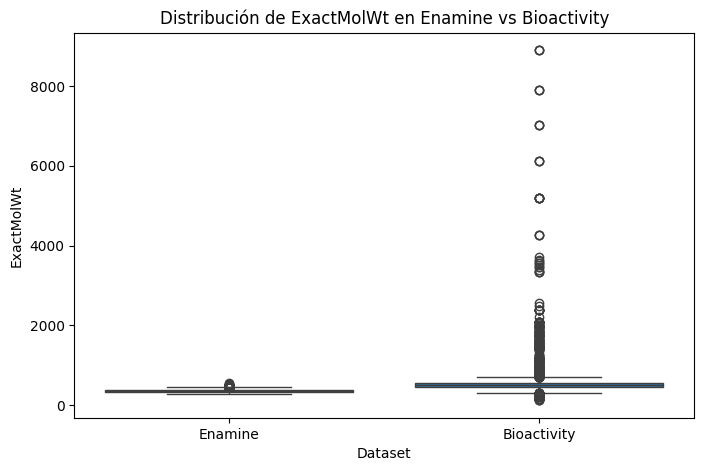

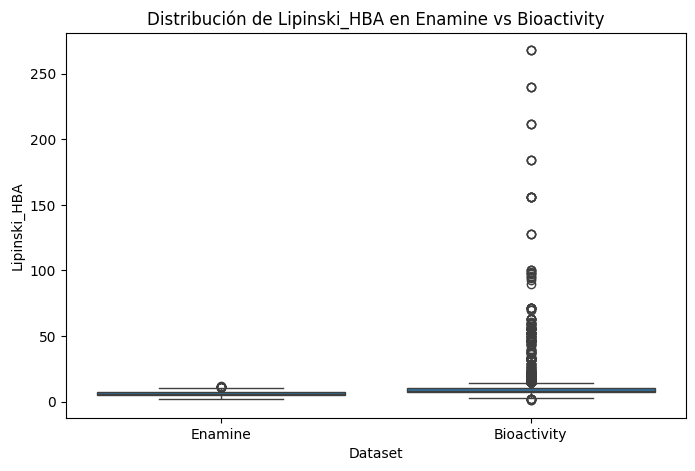

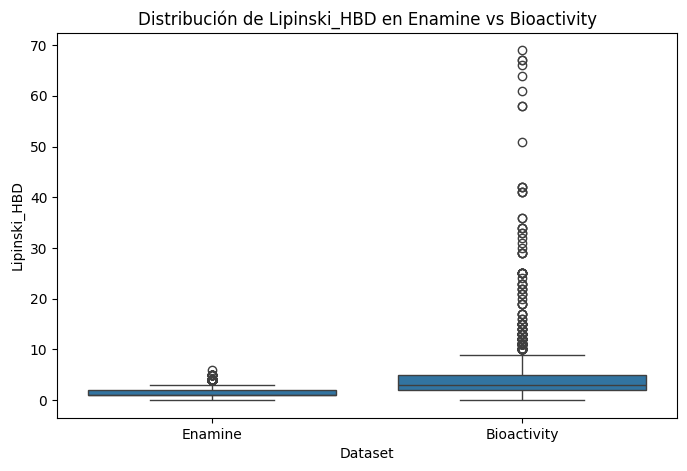

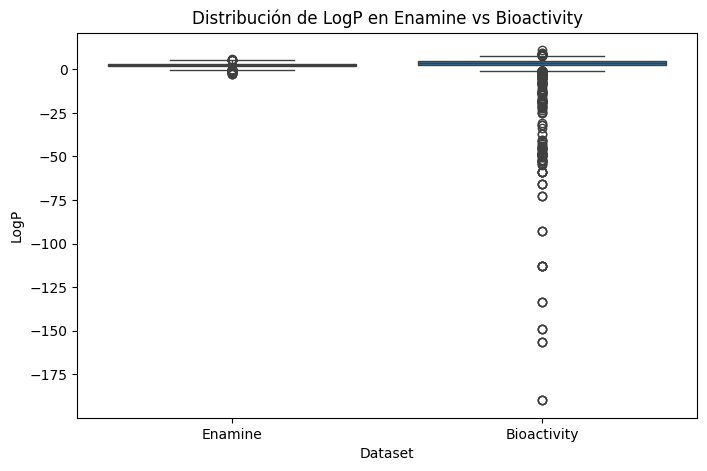

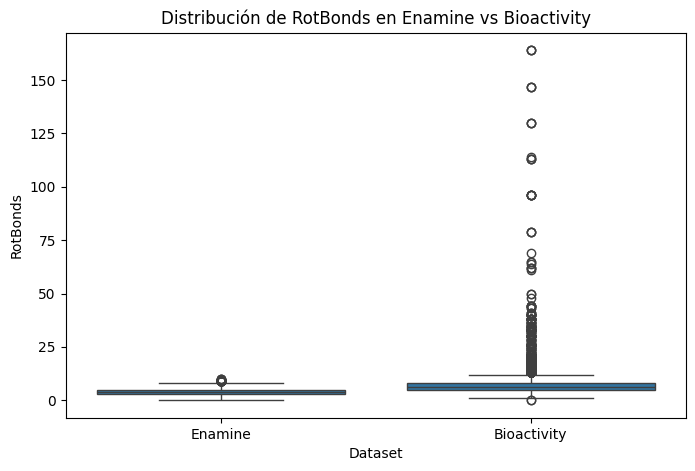

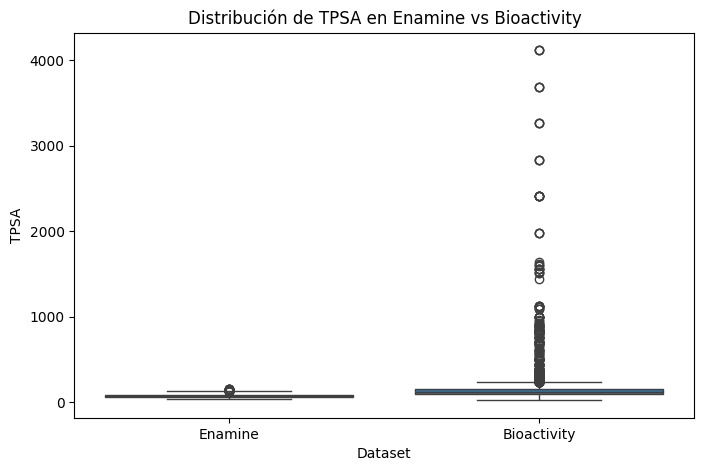


Responda, ¿Cuántos compuestos de cada conjunto de datos no cumplen las reglas de Lipinski y Veber?, ¿Alguno de estos descriptores muestra una marcada diferencia entre los conjuntos de datos?
Compuestos Enamine que NO cumplen Lipinski: 52
Compuestos Bioactivity que NO cumplen Lipinski: 6203

Compuestos Enamine que NO cumplen Veber: 10
Compuestos Bioactivity que NO cumplen Veber: 3063


In [16]:
print("Cálcule los descriptores de Lipinski y Veber para todos los compuestos en ambos conjuntos de datos")
# Creamos una función auxiliar que recibe como entrada el SMILES de cada compuesto, dentro de la función transformamos el
# SMILES en un objeto Mol de RDKit, lo cual nos permite calcular los descriptores fisicoquímicos asociados a las reglas de Lipinski y Veber.
def calcular_lipinski_veber(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        # Lipinski
        "ExactMolWt": rdMolDescriptors.CalcExactMolWt(mol),
        "Lipinski_HBA": rdMolDescriptors.CalcNumLipinskiHBA(mol),
        "Lipinski_HBD": rdMolDescriptors.CalcNumLipinskiHBD(mol),
        "LogP": rdMolDescriptors.CalcCrippenDescriptors(mol)[0],
        # Veber
        "RotBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol)
    }

# Aplicamos nuestra función a cada conjunto de datos:
# Enamine y Bioactivity. Esto genera un diccionario con los descriptores por cada molécula,
# que luego transformamos en un DataFrame y lo anexamos como nuevas columnas.
enamine_desc = enamine["SMILES"].apply(calcular_lipinski_veber)
enamine = enamine.assign(**pd.DataFrame(enamine_desc.tolist()))
bioactivity_desc = bioactivity["Smiles"].apply(calcular_lipinski_veber)
bioactivity = bioactivity.assign(**pd.DataFrame(bioactivity_desc.tolist()))

# Finalmente, verificamos los resultados mostrando las primeras filas de cada conjunto junto con los descriptores calculados,
# para confirmar que se añadieron correctamente.
#print(enamine.head()[["SMILES","ExactMolWt","Lipinski_HBA","Lipinski_HBD","LogP","RotBonds","TPSA"]])
#print(bioactivity.head()[["Smiles","ExactMolWt","Lipinski_HBA","Lipinski_HBD","LogP","RotBonds","TPSA"]])

print("\nConstruya diagramas de caja y bigote (boxplots) comparando las distribuciones de estos descriptores para ambas bases de datos")
# Para poder comparar las distribuciones de los descriptores entre ambos conjuntos,
# unificamos los datos en un solo DataFrame. Esto nos permitirá graficar con seaborn
# y distinguir cada base de datos mediante una columna adicional.
enamine["Dataset"] = "Enamine"
bioactivity["Dataset"] = "Bioactivity"
# Concatenamos ambos DataFrames en uno solo
combined = pd.concat([enamine, bioactivity], ignore_index=True)
# Definimos la lista de descriptores que queremos comparar
descriptores = ["ExactMolWt","Lipinski_HBA","Lipinski_HBD","LogP","RotBonds","TPSA"]
# Generamos un diagrama de caja y bigote para cada descriptor
for desc in descriptores:
    plt.figure(figsize=(8,5))
    sns.boxplot(x="Dataset", y=desc, data=combined)
    plt.title(f"Distribución de {desc} en Enamine vs Bioactivity")
    plt.show()

print("\nResponda, ¿Cuántos compuestos de cada conjunto de datos no cumplen las reglas de Lipinski y Veber?, ¿Alguno de estos descriptores muestra una marcada diferencia entre los conjuntos de datos?")
# Para responder la pregunta, primero definimos las condiciones de cumplimiento
# de las reglas de Lipinski y Veber en cada conjunto de datos.

# Lipinski: Peso molecular < 500, LogP < 5, HBD ≤ 5, HBA ≤ 10
enamine["Lipinski_OK"] = (
    (enamine["ExactMolWt"] < 500) &
    (enamine["LogP"] < 5) &
    (enamine["Lipinski_HBD"] <= 5) &
    (enamine["Lipinski_HBA"] <= 10)
)

bioactivity["Lipinski_OK"] = (
    (bioactivity["ExactMolWt"] < 500) &
    (bioactivity["LogP"] < 5) &
    (bioactivity["Lipinski_HBD"] <= 5) &
    (bioactivity["Lipinski_HBA"] <= 10)
)

# Veber: RotBonds ≤ 10, TPSA ≤ 140
enamine["Veber_OK"] = (
    (enamine["RotBonds"] <= 10) &
    (enamine["TPSA"] <= 140)
)

bioactivity["Veber_OK"] = (
    (bioactivity["RotBonds"] <= 10) &
    (bioactivity["TPSA"] <= 140)
)

# Ahora contamos cuántos compuestos NO cumplen cada regla en cada conjunto
no_lipinski_enamine = (~enamine["Lipinski_OK"]).sum()
no_lipinski_bioactivity = (~bioactivity["Lipinski_OK"]).sum()

no_veber_enamine = (~enamine["Veber_OK"]).sum()
no_veber_bioactivity = (~bioactivity["Veber_OK"]).sum()

print("Compuestos Enamine que NO cumplen Lipinski:", no_lipinski_enamine)
print("Compuestos Bioactivity que NO cumplen Lipinski:", no_lipinski_bioactivity)
print("\nCompuestos Enamine que NO cumplen Veber:", no_veber_enamine)
print("Compuestos Bioactivity que NO cumplen Veber:", no_veber_bioactivity)

**Breve discusión**

**5. Cálculo de huellas digitales moleculares y visualización del espacio químico**

*   Calcule las huellas digitales tipo Morgan (radio 2, 1024 bits) para todos los compuestos de ambos conjuntos.
*   Utilizando los descriptres de interés farmacéutico calculados en la sección anterior, contruya un a visualización del espacio químico en 2D mediante análisis de componentes principales (sin elminiación de datos atípicos) coloreando los puntos de acuerdo al conjunto de datos al que pertenecen.
*   Utilizando las huellas digitales calculadas, consruya una visualización del espacio químico en 2D usando la técnica t-SNE coloreando los puntos de acuerdo al conjunto de datos al que pertenecen.
*   A partir de las visualizaciones generadas responda, ¿El conjunto de compuestos bioactivos ocupa una región compacta o muy dispersa?, ¿Los compuestos de ENAMINE cubren la región ocupada por los compuestos bioactivos o están desplazados de estos?

In [22]:
print("Calcule las huellas digitales tipo Morgan (radio 2, 1024 bits) para todos los compuestos de ambos conjuntos.")
# Creamos un generador Morgan con radio=2 y 1024 bits
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def calcular_morgan(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    # Generamos el fingerprint con el nuevo generador
    fp = morgan_gen.GetFingerprint(mol)
    # Convertimos a arreglo numpy de 0/1
    arr = np.zeros((fp.GetNumBits(),), dtype=int)
    Chem.DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# Aplicamos la función a cada conjunto
enamine["MorganFP"] = enamine["SMILES"].apply(calcular_morgan)
bioactivity["MorganFP"] = bioactivity["Smiles"].apply(calcular_morgan)
"""
# Verificamos resultados para comprobar que no haya errores
print(enamine.head()[["SMILES","MorganFP"]])
print(bioactivity.head()[["Smiles","MorganFP"]])"""
print("\nUtilizando los descriptres de interés farmacéutico calculados en la sección anterior, contruya un a visualización del espacio químico en 2D mediante análisis de componentes principales (sin elminiación de datos atípicos) coloreando los puntos de acuerdo al conjunto de datos al que pertenecen.")

# Primero seleccionamos los descriptores de interés farmacéutico que calculamos previamente.
# Estos incluyen los asociados a Lipinski y Veber: peso molecular, HBA, HBD, LogP, enlaces rotables y TPSA.
features = ["ExactMolWt","Lipinski_HBA","Lipinski_HBD","LogP","RotBonds","TPSA"]

# Creamos un DataFrame combinado con ambos conjuntos de datos y añadimos una columna
# que identifique de qué conjunto proviene cada molécula.
enamine["Dataset"] = "Enamine"
bioactivity["Dataset"] = "Bioactivity"
combined = pd.concat([enamine[features+["Dataset"]],
                      bioactivity[features+["Dataset"]]], ignore_index=True)

# Aplicamos PCA para reducir la dimensionalidad de los descriptores a 2 componentes principales.
pca = PCA(n_components=2)
pca_result = pca.fit_transform(combined[features])

# Añadimos los resultados del PCA al DataFrame combinado para poder graficar.
combined["PC1"] = pca_result[:,0]
combined["PC2"] = pca_result[:,1]

# Generamos la visualización en 2D del espacio químico.
plt.figure(figsize=(8,6))
sns.scatterplot(x="PC1", y="PC2", hue="Dataset", data=combined, alpha=0.6, palette="Set1")
plt.title("Espacio químico en 2D mediante PCA (Lipinski + Veber)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Conjunto de datos")
plt.show()

Calcule las huellas digitales tipo Morgan (radio 2, 1024 bits) para todos los compuestos de ambos conjuntos.
                                            SMILES  \
0      C1=CN(C=N1)C=2C=CC(=CC2)CNCC3=CN4CCCCCC4=N3   
1     CN1N=C(C2=NN=C(COC3CCCCC3)O2)C=4C=CC=CC4C1=O   
2   COC1=CN=C(NC1=O)C2(CCCC2)NCC=3C=CC=4C=CC=CC4C3   
3  CN1C=C(CN[C@H]2C=3C=CC=CC3C[C@@H]2O)C(=N1)C4CC4   
4  O=C(C=1C=CN=C(N1)C=2C=CC=CC2)N3CCC(=O)NCC43COC4   

                                            MorganFP  
0  [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
1  [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
2  [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
3  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
                                              Smiles  \
0  CN(C)Cc1ccccc1-c1ccc(-n2cnc3c(C(F)(F)F)nn(-c4c...   
1  Cc1nn(-c2ccc3onc(N)c3c2)c2c(=O)n(-c3ccc(-c4ccc...   
2  CN(C)Cc1ccccc1-c1ccc(N2CNc3c(C(F)(F)F)nn(-c4cc...   
3  Cc1nc2c(C

**Breve discusión**

**6. Cribado virtual (Mini)**

*   Seleccione un compuesto de referencia dentro de la base de datos de compuestos bioactivos (el más potente, alguno de los fármacos aprobados, etc.) y muestre su estructura.
*   Cálcule la similitud de todos los compuestos en la base de datos Enamine con respecto al compuesto seleccionado y añada ese valor como una columna adicional (Similarity).
*   Construya un histograma con las similitudes obtenidas, señalando el valor que permitiría seleccionar el 1% de las moléculas más parecidas a la molécula de referencia seleccionada.
*   Responda, ¿Cuántas moléculas de Enamine estarían por encima del umbral seleccionado? Considerando la representación y métrica empleada para el cálculo de similitud, ¿Considera que este es un umbral alto o bajo?
*   Seleccione las 10 moléculas más parecidas a las moléculas de referencia y muestre su estructura junto con su identificador.
*   Grafique nuevamente las dos visualizaciones del espacio químico señaladas en la sección anterior, señalando la ubicación de los 10 compuestos seleccionados.
*   Considerando todos los análisis elaborados, explique si considera que esos 10 compuestos serían buenos candidatos para llevarlos a validación experimental frente al blanco biológico estudiado.



**Discusión Final**